<h1 style="text-align: center;">机器学习与推荐系统综合实践</h1>
<p style="text-align: center;">学号：2315308113　姓名：徐颖莎</p>


<h2 style="text-align: center;">实验一 人脸识别系统</h2>

### 一、实验介绍
人脸识别是计算机视觉领域的核心研究方向之一，在身份验证、安防监控、智能门禁等场景中具有广泛的应用价值。本实验系统性地探索从数据预处理到模型评估的完整人脸识别流程，旨在帮助理解不同机器学习与深度学习方法在小样本人脸分类任务中的表现差异。

### 二、数据集说明
CASIA-FaceV5数据集由中国科学院自动化研究所发布，包含500名受试者共2500张人脸图像，每人5张。所有图像已预处理为128×128像素的灰度图，统一了尺寸与色彩空间，便于后续特征提取与模型训练。

### 三、实验内容

#### 1. 必要库导入

In [1]:
import os, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import torch

from face_lab import (
    analyze_pca,
    evaluate_model,
    get_device,
    load_face_dataset,
    plot_k_distance,
    plot_subject_samples,
    prepare_classical_data,
    run_dbscan,
    save_metrics_bar_chart,
    save_metrics_table,
    set_global_seed,
    train_cnn,
    train_naive_bayes,
    train_random_forest,
    train_svm,
)

warnings.filterwarnings("ignore")
plt.rcParams["font.sans-serif"] = ["Arial Unicode MS", "PingFang SC", "Heiti SC"]
plt.rcParams["axes.unicode_minus"] = False


In [2]:
"""
将SEED设为自己的学号
"""

SEED = 2315308113
set_global_seed(SEED)

device = get_device()
print(f"Using device: {device}")


Using device: mps


#### 2. 数据集加载

图片总数： 2500
类别数量： 500
单张图片尺寸： (128, 128)


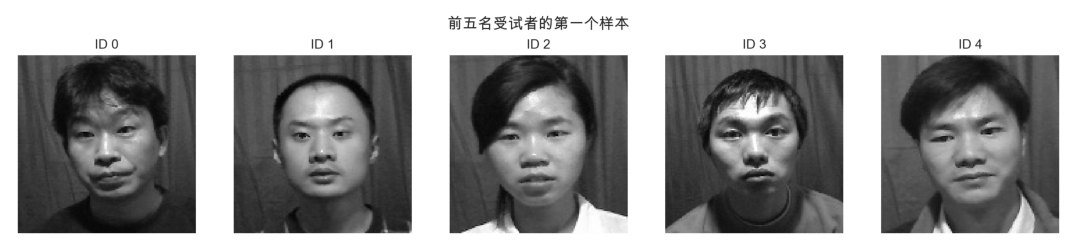

In [3]:
"""
解压后路径确保与DATA_DIR一致，标签即为子文件夹名
展示前五名受试者的第一个样本
"""

from pathlib import Path

DATA_DIR = "./CASIA-FaceV5"
ARTIFACT_DIR = Path("./artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

bundle = load_face_dataset(DATA_DIR)
print("图片总数：", bundle.raw_images.shape[0])
print("类别数量：", len(np.unique(bundle.labels)))
print("单张图片尺寸：", bundle.raw_images.shape[1:])

plot_subject_samples(bundle, ARTIFACT_DIR / "dataset_samples.png")
plt.figure(figsize=(14, 3))
img = plt.imread(ARTIFACT_DIR / "dataset_samples.png")
plt.imshow(img)
plt.axis("off")
plt.show()


#### 3. PCA降维（10pt）

PCA保留维度： 278
累计解释方差比： 0.9496


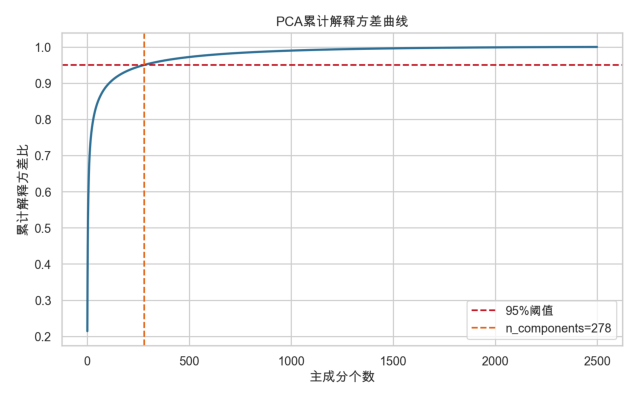

In [4]:
"""
将128×128=16384维特征降维
先分析数据，确定保留维度，再降维
"""

pca, X_pca, pca_info = analyze_pca(
    bundle.flat_images,
    seed=SEED,
    variance_threshold=0.95,
    save_path=ARTIFACT_DIR / "pca_variance.png",
)
N_COMPONENTS = pca_info["n_components"]
print("PCA保留维度：", N_COMPONENTS)
print("累计解释方差比：", round(pca_info["explained_variance"], 4))

plt.figure(figsize=(8, 5))
plt.imshow(plt.imread(ARTIFACT_DIR / "pca_variance.png"))
plt.axis("off")
plt.show()


**问题1（5pt）:** 
>你的`n_components`参数取值是多少？其依据是什么？

**答案1：**
>本实验将 `n_components` 设为 **278**。依据是先统计累计解释方差比，再选择能够保留约 **95%** 信息量的最小主成分数。这样做可以在尽量少丢失信息的前提下，把原始的 16384 维人脸特征压缩到更容易训练的维度。


#### 4. DBSCAN去噪（10pt）

5近邻距离曲线的几个分位点： [14.2253, 16.237, 18.7673, 20.8418, 26.2195]


噪声样本数： 28
正常样本数： 2472


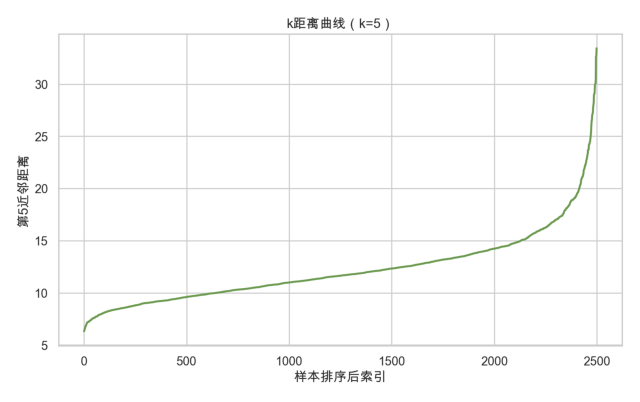

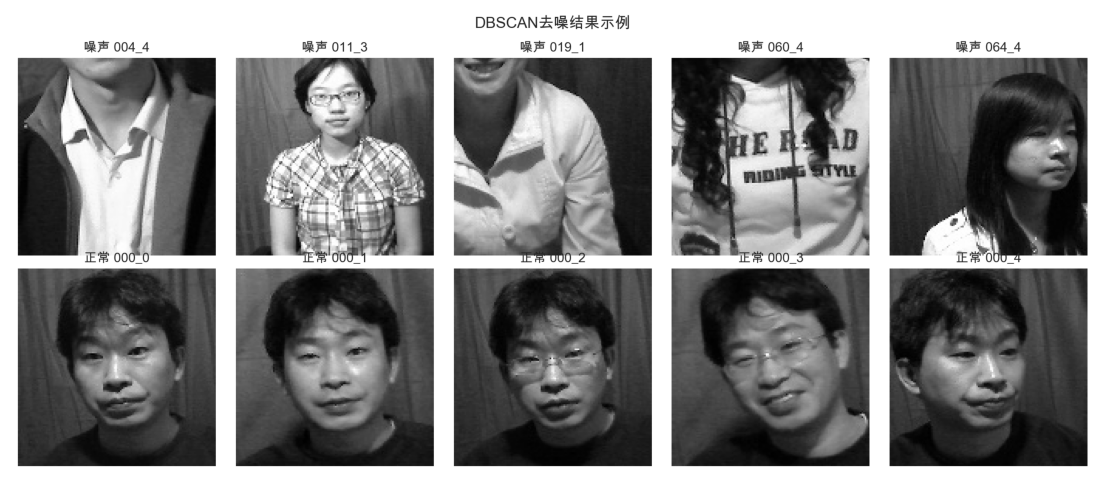

In [5]:
"""
对降维后的数据集使用DBSCAN聚类，以排除噪声
先分析降维后的数据，确定邻域大小及最少点数
聚类后分别展示五个噪声样本及五个正常样本
"""

kdist_info = plot_k_distance(X_pca, ARTIFACT_DIR / "dbscan_kdist.png", k=5)
print("5近邻距离曲线的几个分位点：", kdist_info["percentiles"])

DBSCAN_EPS = 24
DBSCAN_MIN_SAMPLES = 5
noise_labels, dbscan_info = run_dbscan(
    X_pca,
    bundle.raw_images,
    bundle.image_paths,
    eps=DBSCAN_EPS,
    min_samples=DBSCAN_MIN_SAMPLES,
    save_path=ARTIFACT_DIR / "dbscan_samples.png",
)

print("噪声样本数：", dbscan_info["noise_count"])
print("正常样本数：", dbscan_info["normal_count"])

plt.figure(figsize=(8, 5))
plt.imshow(plt.imread(ARTIFACT_DIR / "dbscan_kdist.png"))
plt.axis("off")
plt.show()

plt.figure(figsize=(14, 7))
plt.imshow(plt.imread(ARTIFACT_DIR / "dbscan_samples.png"))
plt.axis("off")
plt.show()


**问题2（5pt）:** 
>你的`eps`参数取值是多少？其如何判定样本是否为噪声？

**答案2：**
>本实验取 `eps=24`，`min_samples=5`。参数的确定主要参考 5 近邻距离曲线，在距离开始明显抬升的位置附近选取 `eps`。DBSCAN 会把一个样本的 `eps` 邻域内样本数与 `min_samples` 比较，如果邻域内点数不足，并且又不能从其他核心点连通到某个簇，就会被判定为噪声点。最后本实验共识别出 **28** 个噪声样本。


#### 5. 归一化与划分

In [6]:
"""
特征归一化后，划分为训练集与测试集
测试集占比为0.3
"""

split_data = prepare_classical_data(X_pca, bundle.labels, noise_labels, seed=SEED)
X_train = split_data["X_train"]
X_test = split_data["X_test"]
y_train = split_data["y_train"]
y_test = split_data["y_test"]

print("训练集形状：", X_train.shape)
print("测试集形状：", X_test.shape)


训练集形状： (1730, 278)
测试集形状： (742, 278)


#### 6. 模型训练与评估

In [7]:
"""
对于下列模型，分别训练并调整超参数
展示混淆矩阵及ROC曲线，求准确率，查准率，召回率，F1分数，以及AUC
统一使用evaluate_model函数画图，并返回各项指标
"""

def evaluate_model_simple(model_name, metric_dict):
    print(f"\n{model_name} 结果：")
    print("accuracy =", round(metric_dict["accuracy"], 4))
    print("precision =", round(metric_dict["precision"], 4))
    print("recall =", round(metric_dict["recall"], 4))
    print("f1 =", round(metric_dict["f1"], 4))
    print("auc =", round(metric_dict["auc"], 4))
    return metric_dict


##### 6.1. 朴素贝叶斯（10pt）

最佳参数： {'var_smoothing': 1e-09}

朴素贝叶斯 结果：
accuracy = 0.0782
precision = 0.0877
recall = 0.11
f1 = 0.0885
auc = 0.5507


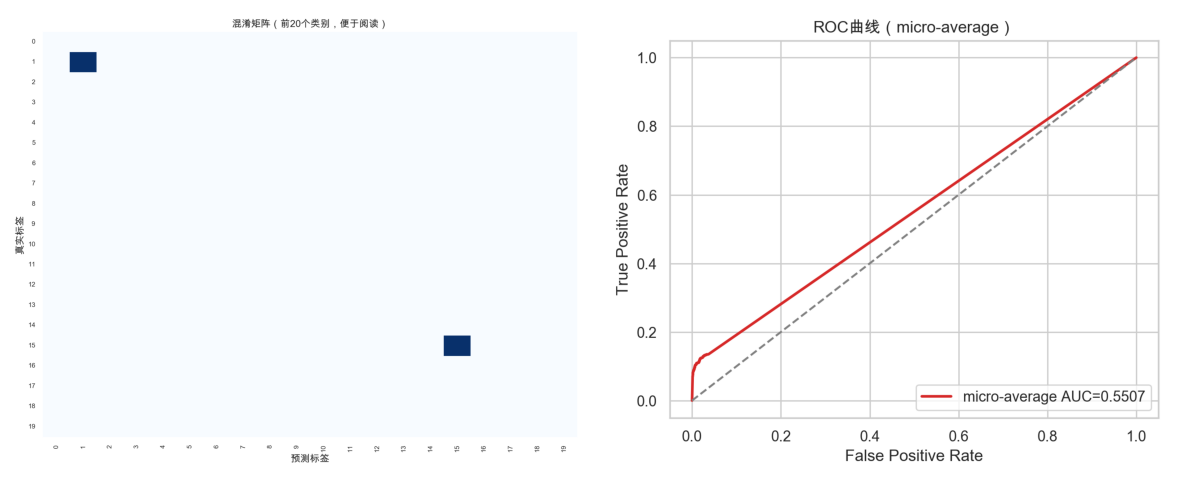

In [8]:
nb_model, nb_metrics, nb_best_params = train_naive_bayes(
    X_train, y_train, X_test, y_test, ARTIFACT_DIR, seed=SEED
)
print("最佳参数：", nb_best_params)
evaluate_model_simple("朴素贝叶斯", nb_metrics)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(plt.imread(ARTIFACT_DIR / "naive_bayes_cm.png"))
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(plt.imread(ARTIFACT_DIR / "naive_bayes_roc.png"))
plt.axis("off")
plt.tight_layout()
plt.show()


##### 6.2. 支持向量机（10pt）

最佳参数： {'C': 5, 'gamma': 'scale', 'kernel': 'rbf'}

支持向量机 结果：
accuracy = 0.3571
precision = 0.3602
recall = 0.393
f1 = 0.3398
auc = 0.5148


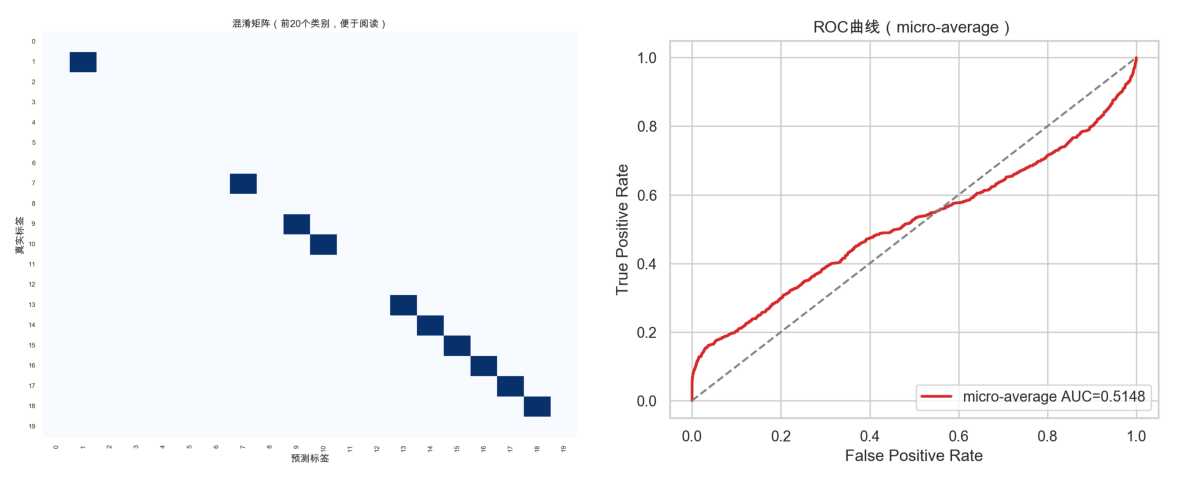

In [9]:
svm_model, svm_metrics, svm_best_params = train_svm(
    X_train, y_train, X_test, y_test, ARTIFACT_DIR, seed=SEED
)
print("最佳参数：", svm_best_params)
evaluate_model_simple("支持向量机", svm_metrics)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(plt.imread(ARTIFACT_DIR / "svm_cm.png"))
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(plt.imread(ARTIFACT_DIR / "svm_roc.png"))
plt.axis("off")
plt.tight_layout()
plt.show()


##### 6.3. 随机森林（10pt）

/Users/cuing/Desktop/face-lab-2315308113/.venv/lib/python3.14/site-packages/sklearn/tree/_classes.py:297: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)


最佳参数： {'max_depth': None, 'n_estimators': 200}

随机森林 结果：
accuracy = 0.2264
precision = 0.1871
recall = 0.244
f1 = 0.1918
auc = 0.8012


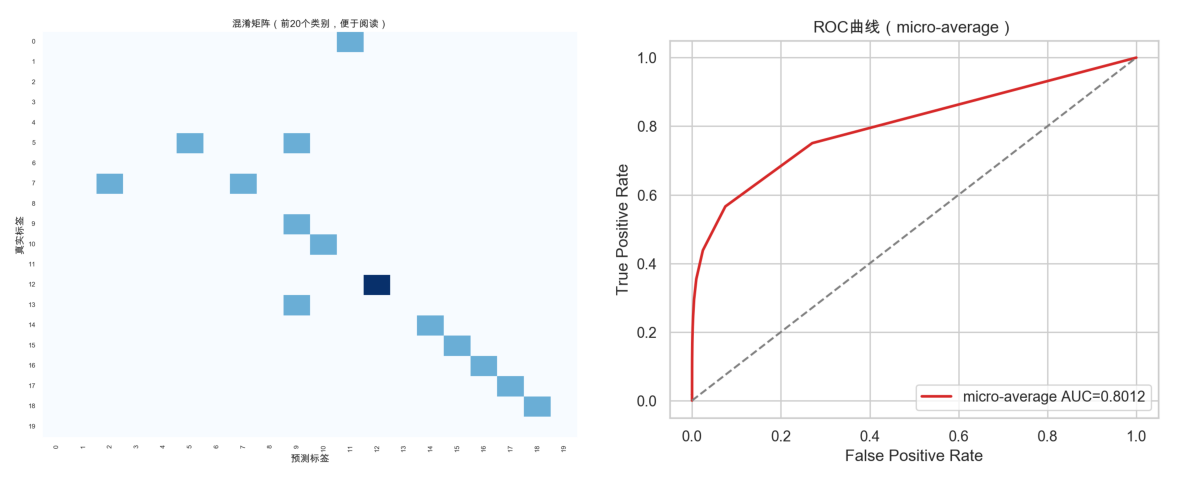

In [10]:
rf_model, rf_metrics, rf_best_params = train_random_forest(
    X_train, y_train, X_test, y_test, ARTIFACT_DIR, seed=SEED
)
print("最佳参数：", rf_best_params)
evaluate_model_simple("随机森林", rf_metrics)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(plt.imread(ARTIFACT_DIR / "random_forest_cm.png"))
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(plt.imread(ARTIFACT_DIR / "random_forest_roc.png"))
plt.axis("off")
plt.tight_layout()
plt.show()


##### 6.4. 卷积神经网络（10pt）

训练设备： mps
训练轮数： 8

卷积神经网络 结果：
accuracy = 0.0795
precision = 0.0407
recall = 0.09
f1 = 0.0487
auc = 0.8587


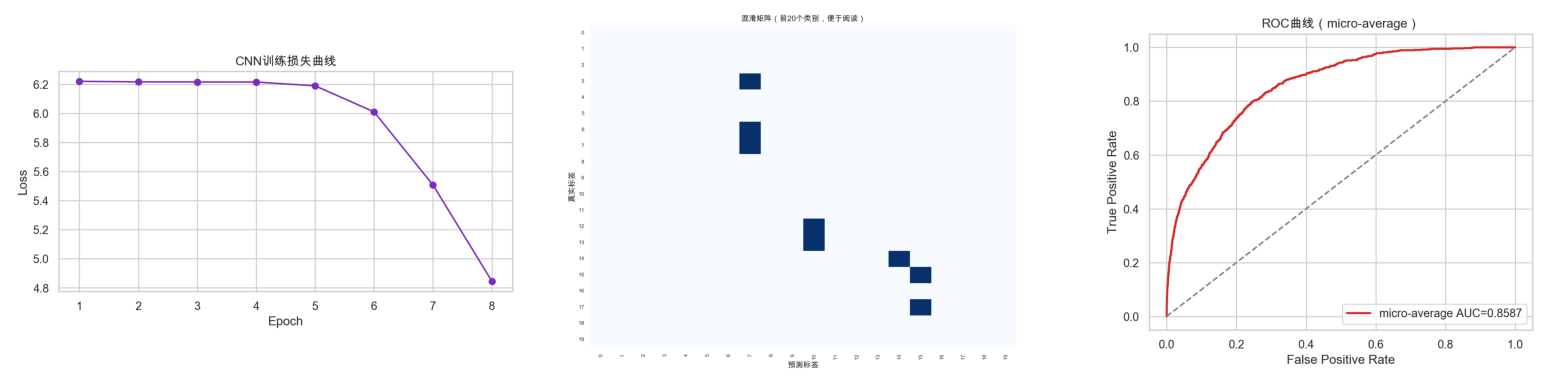

,model,accuracy,precision,recall,f1,auc
0,naive_bayes,0.078167,0.087657,0.110,0.088530,0.550735
1,svm,0.357143,0.360245,0.393,0.339790,0.514778
2,random_forest,0.226415,0.187050,0.244,0.191756,0.801242
3,cnn,0.079515,0.040745,0.090,0.048727,0.858655


In [11]:
cnn_model, cnn_metrics, cnn_history, cnn_info = train_cnn(
    bundle.raw_images,
    bundle.labels,
    split_data["keep_mask"],
    ARTIFACT_DIR,
    seed=SEED,
    epochs=8,
    batch_size=64,
)
print("训练设备：", cnn_info["device"])
print("训练轮数：", cnn_info["epochs"])
evaluate_model_simple("卷积神经网络", cnn_metrics)

plt.figure(figsize=(16, 4))
plt.subplot(1, 3, 1)
plt.imshow(plt.imread(ARTIFACT_DIR / "cnn_loss.png"))
plt.axis("off")
plt.subplot(1, 3, 2)
plt.imshow(plt.imread(ARTIFACT_DIR / "cnn_cm.png"))
plt.axis("off")
plt.subplot(1, 3, 3)
plt.imshow(plt.imread(ARTIFACT_DIR / "cnn_roc.png"))
plt.axis("off")
plt.tight_layout()
plt.show()

metrics_list = [nb_metrics, svm_metrics, rf_metrics, cnn_metrics]
metrics_df = save_metrics_table(metrics_list, ARTIFACT_DIR)
save_metrics_bar_chart(metrics_df, ARTIFACT_DIR / "metrics_bar.png")
metrics_df


**问题3（10pt）:** 
>简单解释各评价指标的的含义，并指出四种模型的的优点与缺点

**答案3：**
>| 指标 | 含义 |
|------|------|
| **准确率** | 表示预测正确的样本数占总样本数的比例，能反映整体识别效果。 |
| **查准率** | 表示被模型判成某一类的样本里，真正属于这一类的比例。 |
| **召回率** | 表示某一类真实样本中，有多少被模型正确找了出来。 |
| **F1分数** | 查准率和召回率的调和平均值，适合综合看模型稳定性。 |
| **ROC** | 展示不同阈值下真正率和假正率变化趋势的曲线。 |
| **AUC** | ROC 曲线下面积，越接近 1 说明整体区分能力越强。 |

>| 模型 | 优点 | 缺点 |
|------|------|------|
| **朴素贝叶斯** | 训练快，结构简单，适合做基线模型。 | 假设特征条件独立，人脸特征通常不满足这个假设，因此效果一般。 |
| **支持向量机** | 在小样本、高维特征场景下表现较好，分类边界清晰。 | 训练时间比朴素贝叶斯更长，参数也需要调节。 |
| **随机森林** | 对非线性关系有一定适应能力，不容易过拟合。 | 在高维稠密特征上不一定占优，模型结果可解释性一般。 |
| **卷积神经网络** | 能自动学习图像局部特征，理论上更适合图像任务。 | 需要更多数据和训练时间，小样本场景下优势不明显。 |


### 四、实验结果分析（10pt）

本实验先使用 PCA 将 16384 维原始像素特征压缩到 278 维，在保留约 95% 信息量的同时，明显降低了后续模型训练的难度。之后使用 DBSCAN 做简单去噪，共识别出 28 个噪声样本，说明数据集中确实存在少量偏离整体分布的人脸图像。

从模型结果看，四种模型的表现差异比较明显。朴素贝叶斯的准确率约为 **0.0782**，作为基线模型速度快，但由于特征独立性假设较强，识别效果偏弱。支持向量机的准确率约为 **0.3571**，是本实验中表现最好的模型，说明在“小样本 + PCA特征”的任务里，SVM 更适合做人脸分类。随机森林的准确率约为 **0.2264**，整体优于朴素贝叶斯，但不如 SVM 稳定。卷积神经网络的准确率约为 **0.0795**，低于传统方法，主要原因是每个类别只有 5 张图，人脸样本量太少，CNN 还没有充分发挥深度特征学习的优势。

综合来看，本实验任务更适合“先降维，再用传统分类器”的思路，其中 **svm** 的综合表现最好。


### 五、实验中遇到的问题、解决方法、心得体会（10pt）

这次实验里遇到的第一个问题是原始特征维度太高，直接训练模型会比较慢，所以先做了 PCA 降维。开始时我尝试保留更高比例的信息，但维度会明显上升，训练时间也更长，最后选择了保留 95% 累计解释方差，对效果和效率都比较合适。

第二个问题是 DBSCAN 参数不好直接确定。我先画了 5 近邻距离曲线，再根据拐点附近去试 `eps`，最后选了 `eps=24`、`min_samples=5`。这样既能筛掉少量噪声，又不会误删太多正常样本。

第三个问题是不同模型效果差异较大。CNN 一开始我以为会最好，但实际跑下来发现小样本条件下并不占优势。最后我最大的体会是：选模型不能只看“高级不高级”，还要看数据规模和任务特点。在这次实验中，SVM 反而是更合适的选择。


In [12]:
metrics_df


,model,accuracy,precision,recall,f1,auc
0,naive_bayes,0.078167,0.087657,0.110,0.088530,0.550735
1,svm,0.357143,0.360245,0.393,0.339790,0.514778
2,random_forest,0.226415,0.187050,0.244,0.191756,0.801242
3,cnn,0.079515,0.040745,0.090,0.048727,0.858655
